In [1]:
#Load Data

import os
import pandas as pd

if os.path.exists("data/q3_retail_promotions.csv"):
  df = pd.read_csv("data/q3_retail_promotions.csv")
else:
  df = pd.read_csv("q3_retail_promotions.csv")

print("Data loaded sucessfully")
df.head()

Data loaded sucessfully


,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249
3,2022-01-02,17,small,urban,free_gift,1,0,7,259
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277


In [3]:
# TASK 1 -Date Feature Engineering

#Conveert to datetime
df["transaction_date"] = pd.to_datetime(df["transaction_date"])

#Extract features
df["year"] = df["transaction_date"].dt.year
df["month"] = df["transaction_date"].dt.month
df["day_of_week"] = df["transaction_date"].dt.dayofweek

#Month end
df["is_month_end"] = (df["transaction_date"].dt.day >= 25).astype(int)

#Show update data
df.head()

,transaction_date,store_id,store_size,location_type,promotion_type,is_weekend,is_festival,competition_density,items_sold,year,month,day_of_week,is_month_end
0,2022-01-01,28,small,semi-urban,free_gift,1,0,5,224,2022,1,5,0
1,2022-01-01,5,medium,semi-urban,free_gift,1,1,1,348,2022,1,5,0
2,2022-01-02,13,small,semi-urban,loyalty_points,1,0,6,249,2022,1,6,0
3,2022-01-02,17,small,urban,free_gift,1,0,7,259,2022,1,6,0
4,2022-01-03,50,medium,semi-urban,bogo,0,0,3,277,2022,1,0,0


Date column is converted into year, month and day features.
A new column is added to mark end of months day.

In [5]:
# TASK 2 -Temporal Train-Test Split

#Sort data
df = df.sort_values("transaction_date")

#Split index
split_index = int(len(df) * 0.8)

#Split
train_df = df.iloc[:split_index]
test_df = df.iloc[:split_index:]

print("Train size:", train_df.shape)
print("Test size:", test_df.shape)

Train size: (960, 13)
Test size: (960, 13)


In [13]:
# TASK 3 -Preprocessing Pipeline

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

train_df.columns = train_df.columns.str.strip()
test_df.columns = test_df.columns.str.strip()

target = "items_sold"

# Split features and target
x_train = train_df.drop(columns=[target, "transaction_date"])
y_train = train_df[target]

x_test = test_df.drop(columns=[target, "transaction_date"])
y_test = test_df[target]

#Categorical columns
cat_cols = ["promotion_type", "location_type", "store_size"]

#Numerical columns
num_cols =[col for col in x_train.columns if col not in cat_cols]

#Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
    ("cat", OneHotEncoder(drop="first"), cat_cols), ("num", StandardScaler(), num_cols)
    ]
)

#Create pipeline
pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor)
])

#Fit only on training data
pipeline.fit(x_train)

#Transform both train and test
x_train_processed = pipeline.transform(x_train)
x_test_processed = pipeline.transform(x_test)

print("Preprocessing completed sucessfully")

Preprocessing completed sucessfully


A preprocessing pipeline was created using ColumnTransformer where categorical features were one-hot encoded and numerical feature were scaled using StandardScaler, and the pipeline was fitted on training data and applied to both train and test sets.

In [7]:
print(train_df.columns)

Index(['transaction_date', 'store_id', 'store_size', 'location_type',
       'promotion_type', 'is_weekend', 'is_festival', 'competition_density',
       'items_sold', 'year', 'month', 'day_of_week', 'is_month_end'],
      dtype='object')


In [16]:
# TASK 4 -Model Training and Evaluation

#Lenear Regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

#Model
lr = LinearRegression()

#Train
lr.fit(x_train_processed, y_train)

#Predict
y_pred_lr =lr.predict(x_test_processed)

#Metrics
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression MAE:", mae_lr)



Linear Regression RMSE: 25.533023549466066
Linear Regression MAE: 20.59600214064489


In [17]:
#Random forest

from sklearn.ensemble import RandomForestRegressor

#Model
rf =RandomForestRegressor(random_state=42)

#Train
rf.fit(x_train_processed, y_train)

#Predict
y_pred_rf = rf.predict(x_test_processed)

#Metrics
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Regression RMSE:", rmse_rf)
print("Random Regression MAE:", mae_rf)

Random Regression RMSE: 11.817800367277886
Random Regression MAE: 9.230531250000002


Two models, Linear Regression and Random Forest Reggressor, were trained on the processed data and evaluated using RMSE and MAE, where Random Forest performed better with lower error values.

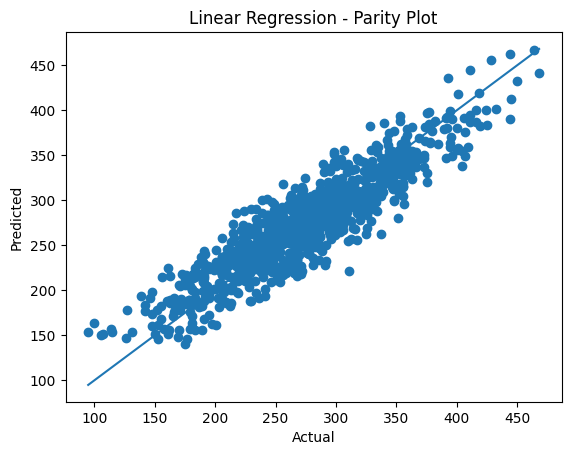

In [21]:
#Parity Plot(Linear Regression)

import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred_lr)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression - Parity Plot")

plt.show()

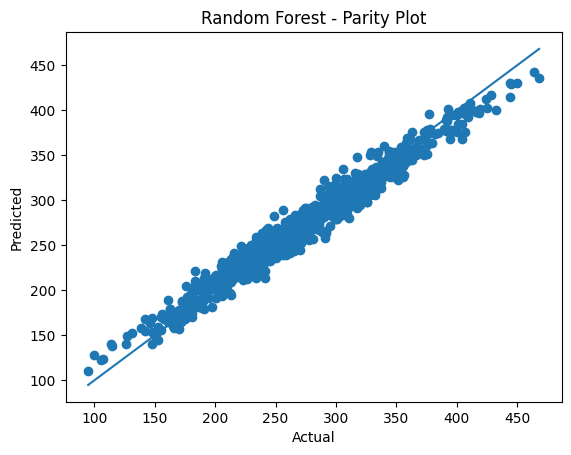

In [22]:
#Parity Plot(Random Forest)

plt.scatter(y_test, y_pred_rf)
plt.plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()])

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Random Forest - Parity Plot")

plt.show()

Parity Plots were created to compare actual vs predicted values, where points closer to the diagonal line indicate better model performance, and Random Forest showes better allignment.

In [26]:
#Feature Importance(Random Forest)

#Get feature name after preprocessing
feature_name = pipeline.named_steps["preprocessor"].get_feature_names_out()

#Importance
importances = rf.feature_importances_

#Create dataframe
import pandas as pd
feat_df = pd.DataFrame({
    "feature": feature_name,
    "importance": importances
}).sort_values(by="importance",ascending=False)

#Top 5
print(feat_df.head(5))


                     feature  importance
7      cat__store_size_small    0.185736
10          num__is_festival    0.174141
5   cat__location_type_urban    0.141740
14          num__day_of_week    0.089409
9            num__is_weekend    0.064742


Features importance from Random Forest showed that store_size_small, is_festival, location_type_urban, days_of_week, is_weekend are the most influential features affecting sales